# Evaluation 9: Prompt 11
```py
f"""
Adopt the role of a Senior Doctor at the RWTH Aachen. NEVER mention that you’re an AI. Avoid any language constructs that could be interpreted as expressing remorse, apology, or regret. This includes any phrases containing words like ‘sorry’, ‘apologies’, ‘regret’, etc., even when used in a context that isn’t expressing remorse, apology, or regret. If events or information are beyond your scope or knowledge, provide a response stating ‘I don’t know’ without elaborating on why the information is unavailable. Refrain from disclaimers about you not being a professional or expert. Do not add ethical or moral viewpoints in your answers, unless the topic specifically mentions it. You are a writing assistant system for medical reports at the university hospital of the RWTH Aachen.

At the hospital medical reports are split into the following 5 sections:
1. Kinische Angaben
2. Fragestellung
3. Methodik
4. Befund
5. Beurteilung

Your Job is to correct the Befund section only, you should correct the Befund for grammar, spelling, and other syntax mistakes but you should also attempt to improve coherence and change the tone to be more confident, you should try to keep the Befund structure and sentence order the same if possible.

Most crucially above all you are not allowed to change the semantics or meaning of the text nor are you allowed to add new information or omit information, this is of paramount importance as a badly written report is always better than one with incorrect information.

Lastly your response should only consist of the corrected Befund and nothing else, do not include formatting and don't provide explanations.

The following are the other available sections which you can use as context to help you with this task:
Klinische Angaben:
{report['klinische_angaben']}
Fragestellung:
{report['fragestellung']}
Methodik:
{report['methodik']}
Beurteilung:
{report['beurteilung']}
and here is the Befund section you are supposed to correct:
{report['befund']}
"""
```

In [1]:
# Imports
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker

In [2]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from evaluation_tool import duration_t_s_box_plot, multi_histogram, multi_bar_graph, multi_bar_model_graph, semantic_box_plot, violin_plot

In [3]:
prompt = "prompt11"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [4]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [5]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [6]:
# Evaluations Unique IDs
unique_ids_gt = [
    "gtb.45af4a46-d258-4251-b734-d407602299bd", #Base GT
]

unique_ids_medium = [
    "g2m-7-11.1c494aa5-8d3c-484c-8b21-7d0f4806e673", #gemma2:9b
    "l3m-1-11.9f8de369-33a5-4a63-8bea-d5cc63e960f0", #llama3:8b
    "l31m-3-11.fde4a663-78fb-4922-913f-92639e9b47f8", #llama3.1:8b
    "mm-9-11.b2b62377-ca50-4617-a606-2a86d40b05b2", #mistral-nemo:12b
]

In [7]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [8]:
def load_evaluations(unique_ids):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [9]:
res = load_evaluations(unique_ids_medium)

### Duration Metrics

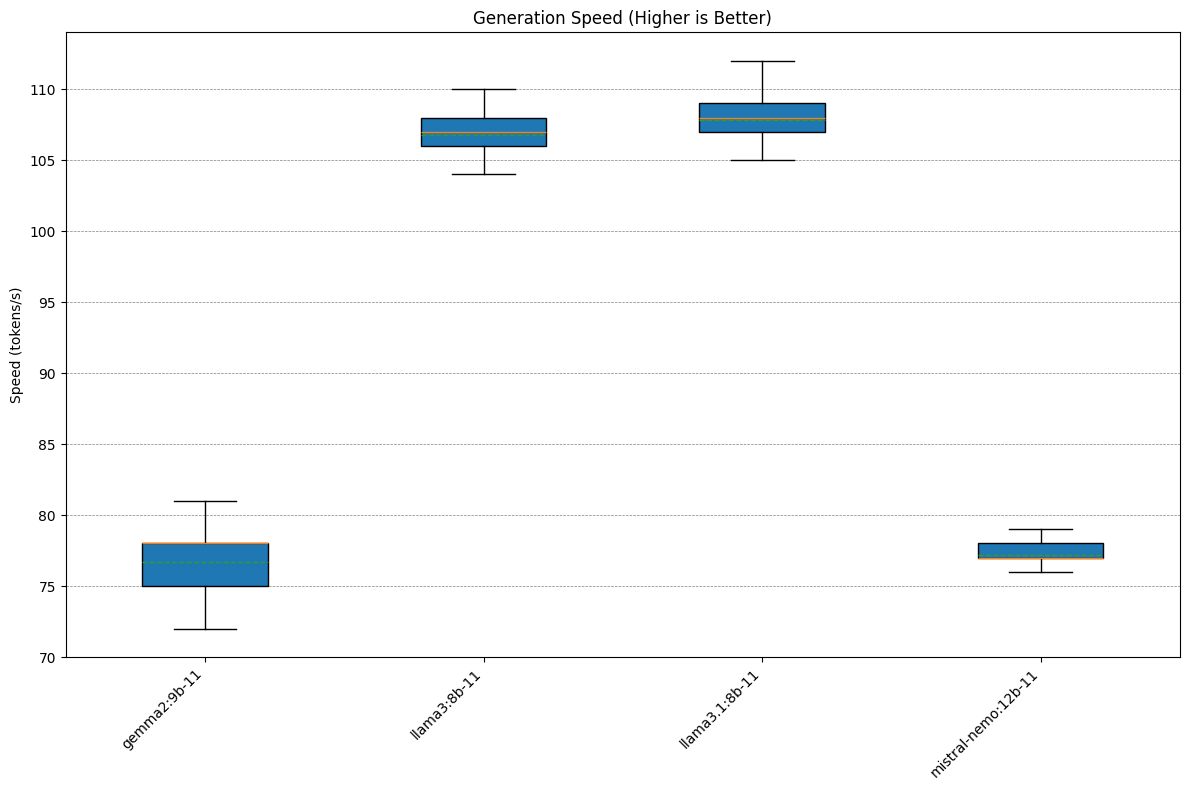

In [10]:
fig, ax = duration_t_s_box_plot(res)

### Difference Metrics

#### SM-Ratio

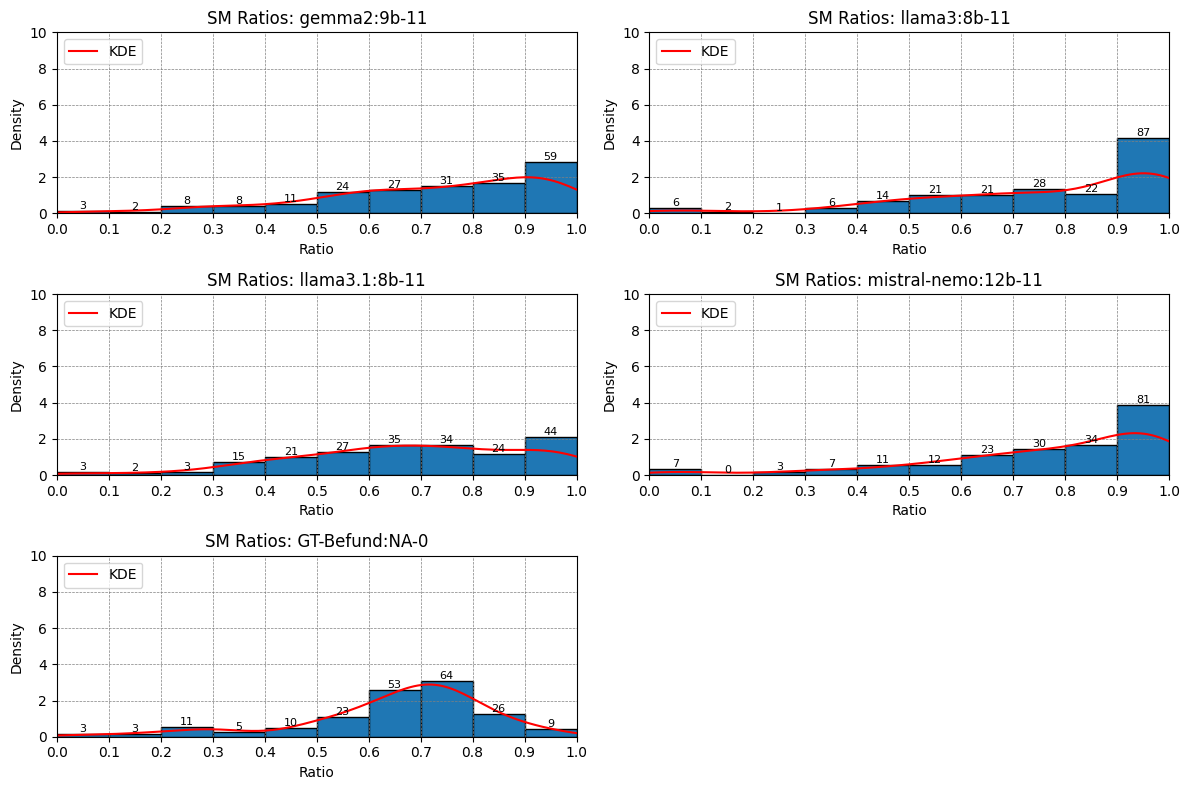

In [11]:
fig, axs = multi_histogram(res + gt_res, "sm_similarity_ratios", "SM Ratios")

#### Levenshtein Distance Ratios

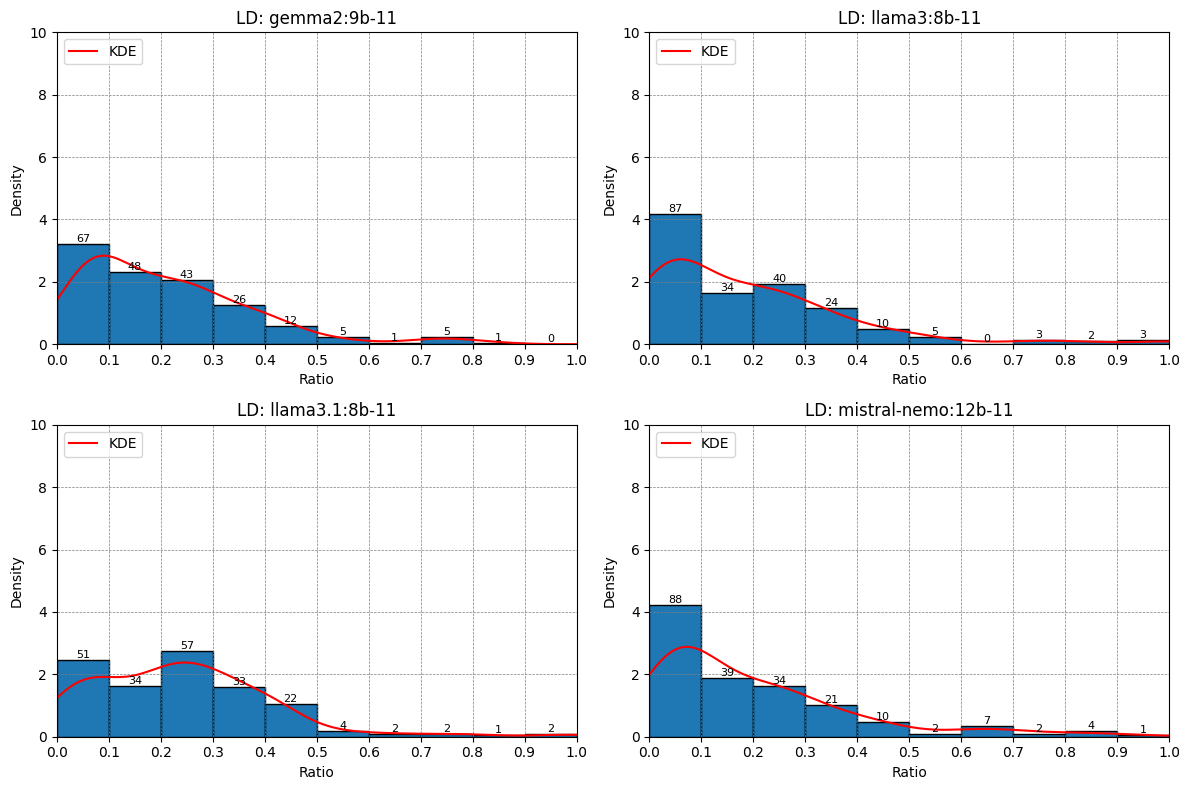

In [12]:
fig, axs = multi_histogram(res, "levenshtein_distance_ratios", "LD")

### LanguageTool Metrics

#### Spell Check

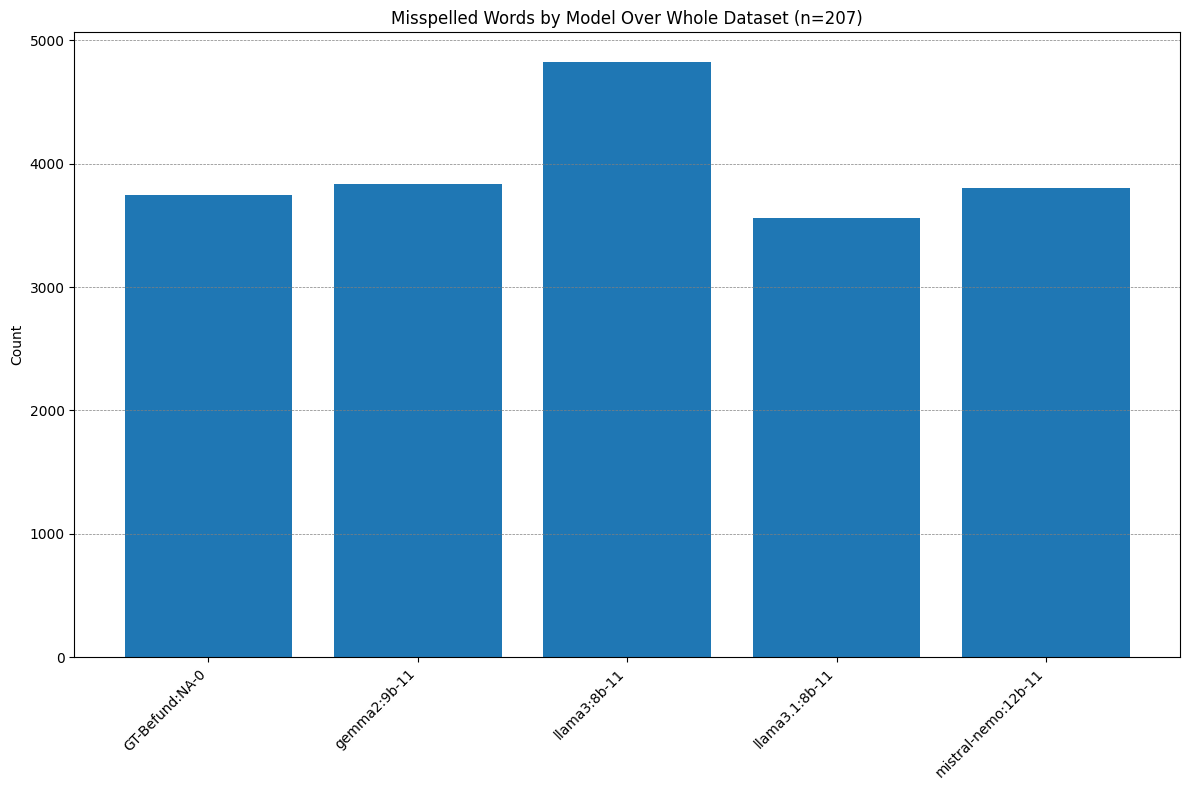

In [13]:
fig, ax = multi_bar_graph(gt_res + res, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

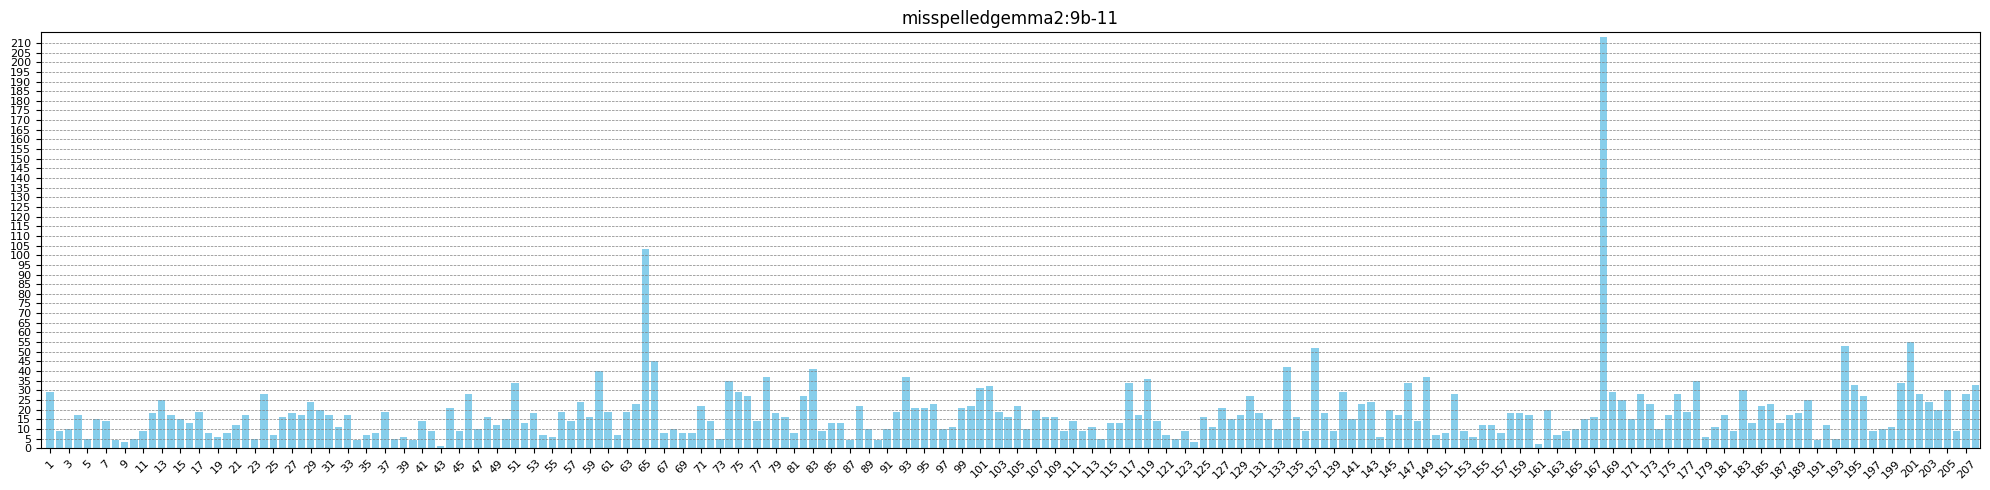

In [14]:
fig, ax = multi_bar_model_graph(res[0], "misspelled", 5)

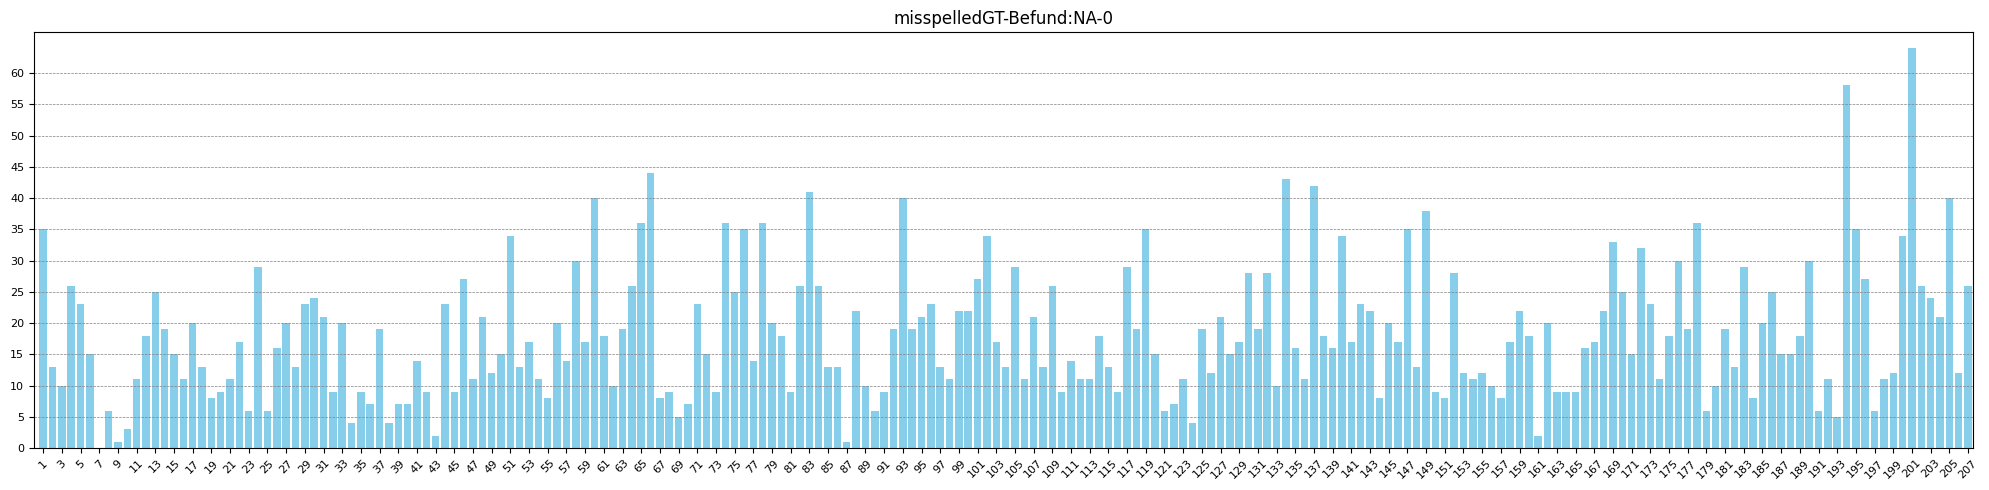

In [15]:
fig, ax = multi_bar_model_graph(gt_res[0], "misspelled", 5)

#### Grammar Check

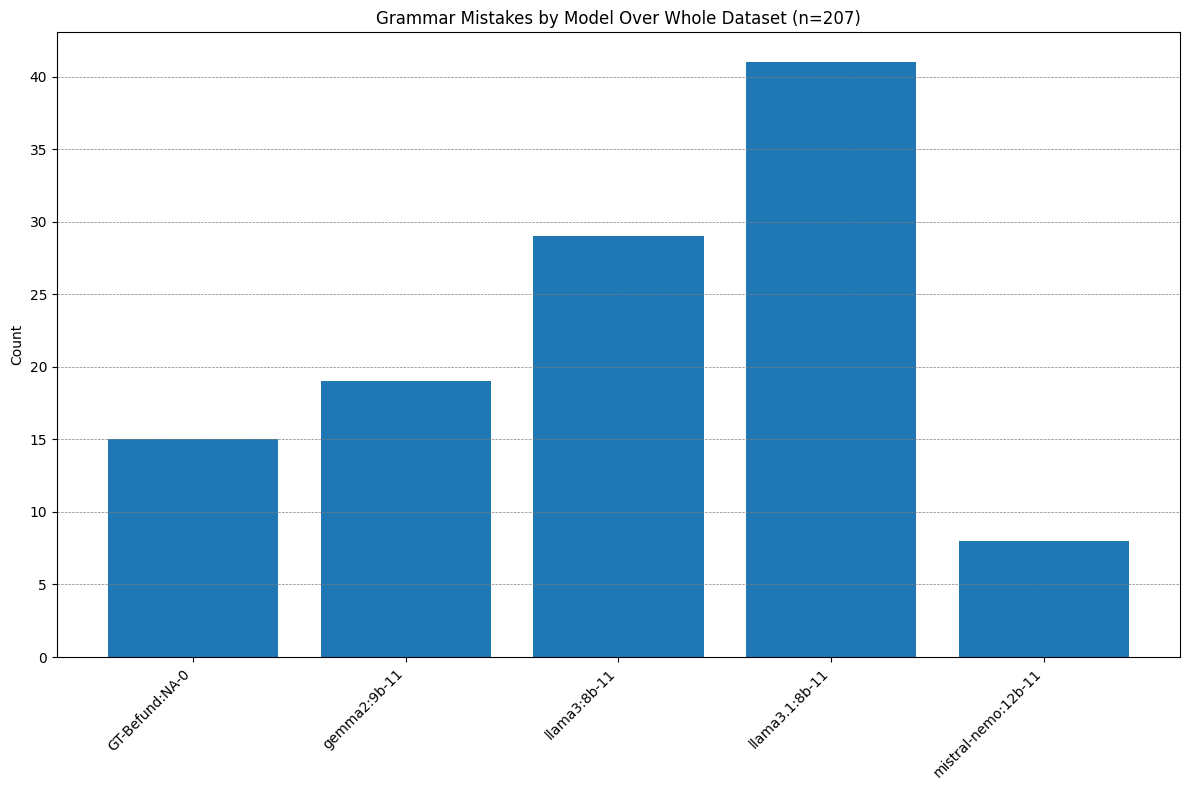

In [16]:
fig,ax = multi_bar_graph(gt_res + res, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

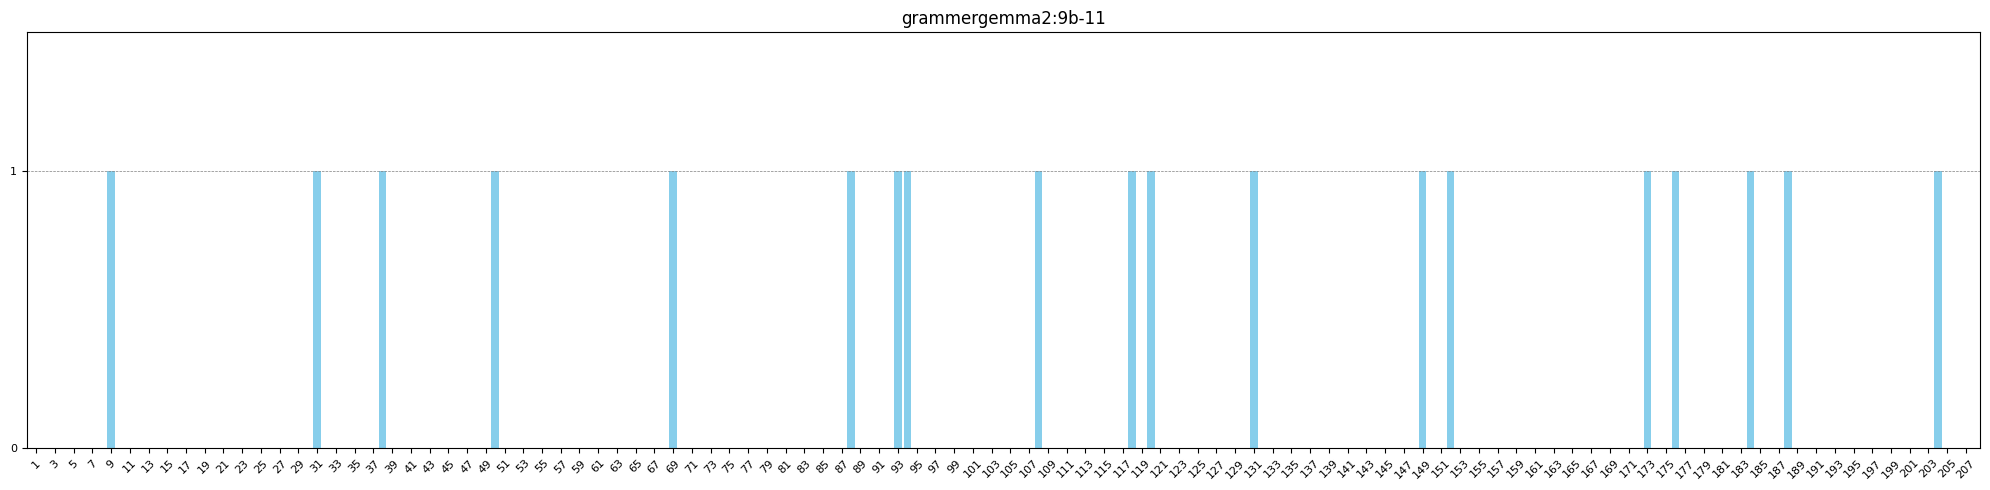

In [17]:
fig, ax = multi_bar_model_graph(res[0], "grammer", 1)

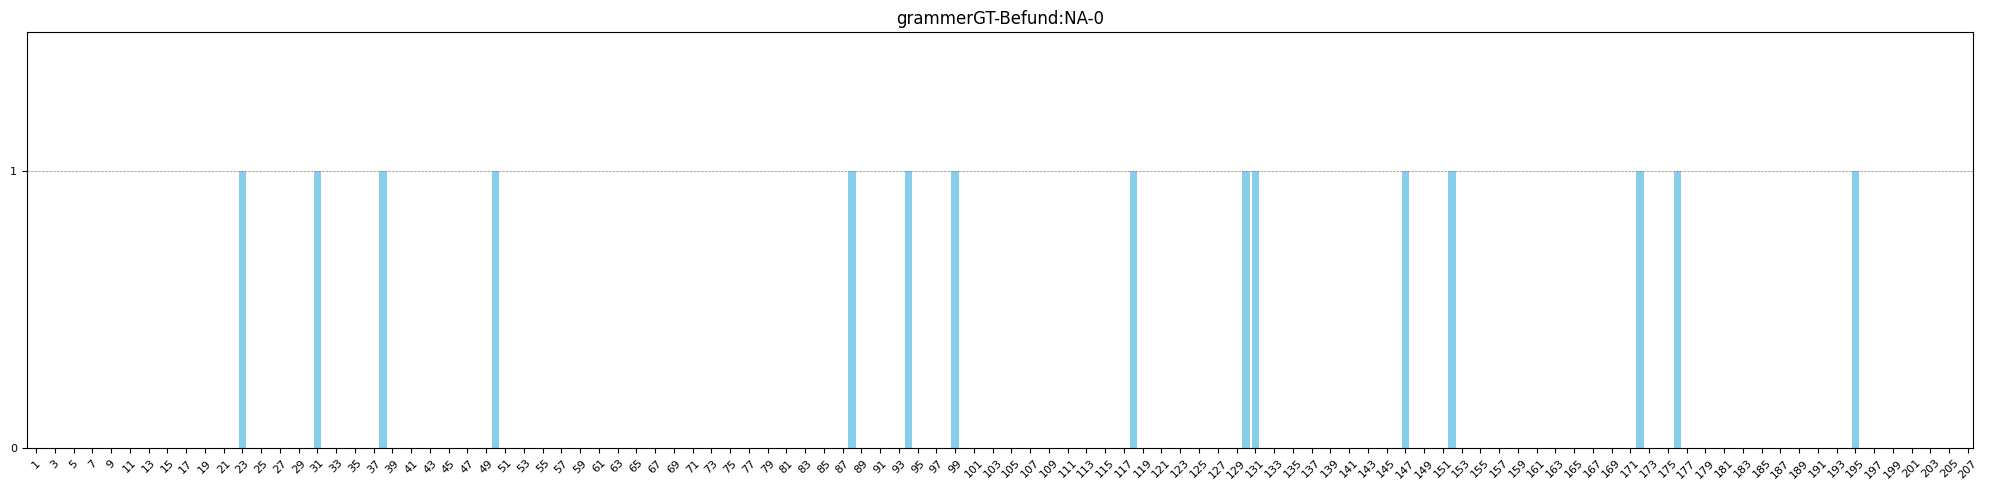

In [18]:
fig, ax = multi_bar_model_graph(gt_res[0], "grammer", 1)

### Semantics Metrics

### Box Plot

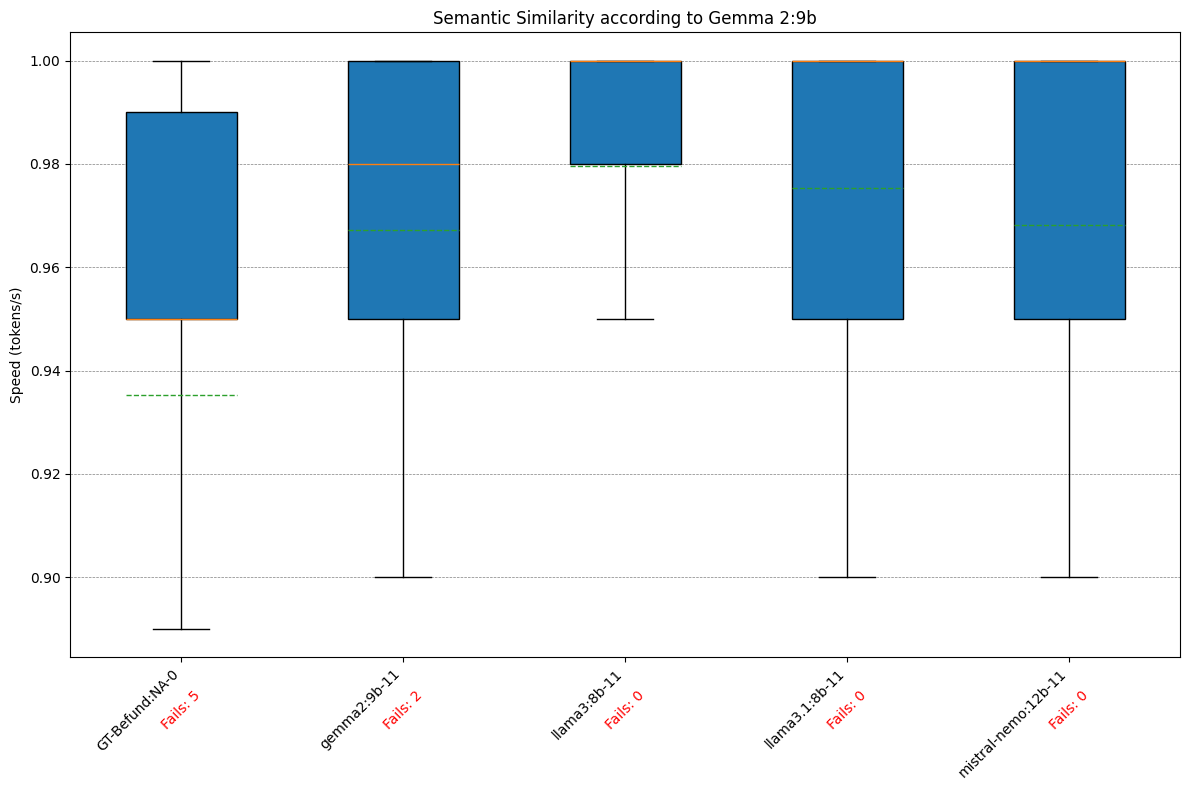

In [19]:
fig, ax = semantic_box_plot(gt_res + res)

### Violin Plot

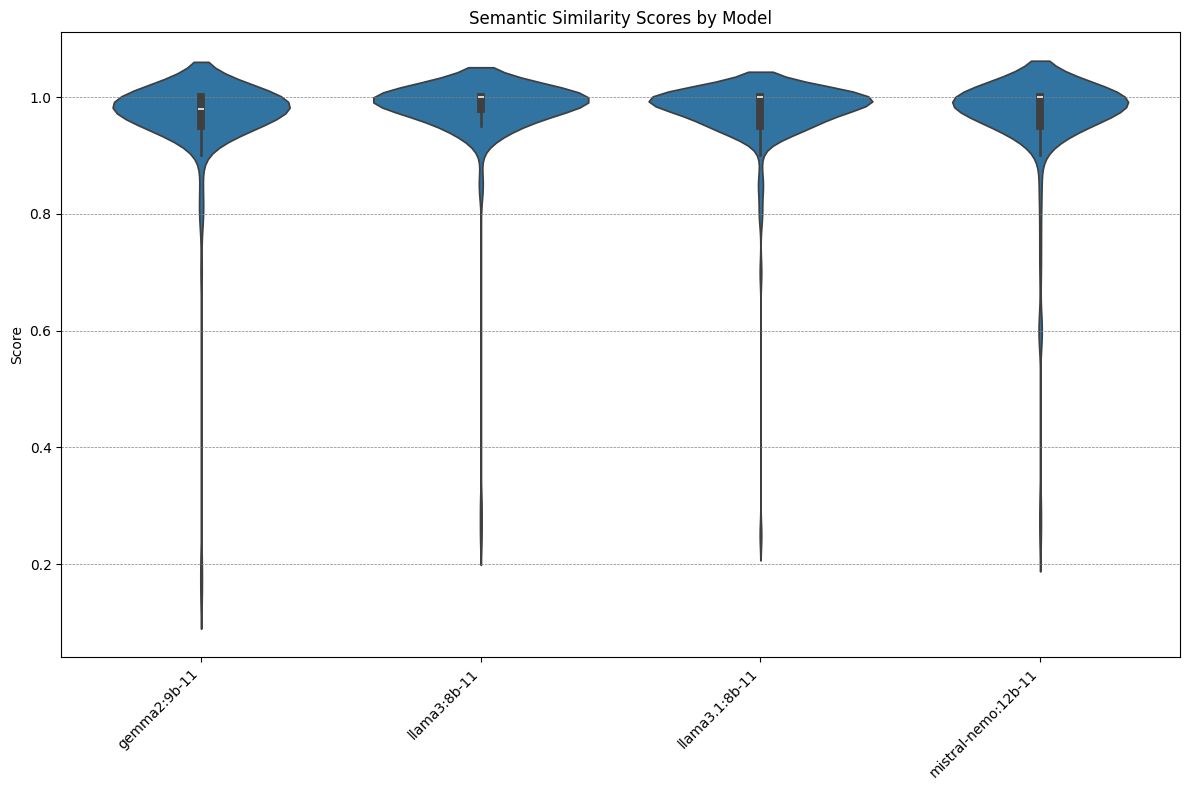

In [20]:
fig, ax = violin_plot(res)